In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [2]:
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
from eval.eval import *

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
############################################################

In [6]:
### SETTINGS ###
config = load_config()

OmegaConf.set_struct(config, False)
config.pc_dim = 100
adata = process_data(pc_dim=config.pc_dim, data="zebrafish")
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

config.num_classes = adata.obs['cell_type'].nunique()
project = "zebrafish"

#######################


/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/azweig/projects/finfm/utils/lineage.py:75: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['stoi'] = stoi


In [7]:
# #CFM
# config.metric = "cfm"
# config.no_learning = True

# config.method = "exact"

In [8]:
# #CFM + UOT
# config.metric = "cfm"
# config.no_learning = True

# config.method = "unbalanced"
# config.reg = 0.01
# config.reg_m = 1.0

In [9]:
#CFM + Finsler + UOT
config.metric = "cfm"
config.no_learning = False

config.finsler.use = True
config.finsler.lamb = 10.0
config.dummy_kl_weight = 0.2

config.classifier_max_epochs = 1000
config.metric_max_epochs = 2
config.embed_max_epochs = 2000
config.flow_max_epochs = 2

config.method = "unbalanced"
config.reg = 0.01
config.reg_m = 1.0

In [10]:
# #MFM-Euc
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.classifier_max_epochs = 1000
# config.metric_max_epochs = 1000
# config.embed_max_epochs = 2000
# config.flow_max_epochs = 2

# config.method = "exact"

In [11]:
# #MFM-Euc + UOT
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.classifier_max_epochs = 1000
# config.metric_max_epochs = 1000
# config.embed_max_epochs = 2000
# config.flow_max_epochs = 2

# config.method = "unbalanced"
# config.reg = 0.01
# config.reg_m = 1.0

In [12]:
# #MFM + Finsler + UOT
# config.metric = "mfm"

# config.finsler.use = True
# config.finsler.lamb = 5.0
# config.dummy_kl_weight = 0.3

# config.classifier_max_epochs = 1000
# config.metric_max_epochs = 1000
# config.embed_max_epochs = 2000
# config.flow_max_epochs = 2

# config.method = "unbalanced"
# config.reg = 0.01
# config.reg_m = 1.0

In [13]:
adata

AnnData object with n_obs × n_vars = 65554 × 4569
    obs: 'cell', 'Size_Factor', 'n.umi', 'perc_mitochondrial_umis', 'timepoint', 'hash_umis', 'top_to_second_best_ratio', 'expt', 'cell_type_sub', 'cell_type_broad', 'tissue', 'germ_layer', 'log.n.umi', 'num_genes_expressed', 'umap3d_1', 'umap3d_2', 'umap3d_3', 'major_group', 'gene_target', 'mean_nn_time', 'subumap3d_1', 'subumap3d_2', 'subumap3d_3', 'embryo', 'temp', 'n_genes', 'cell_type', 'cell_type_one_hot'
    var: 'gene_short_name', 'id', 'chromosome', 'bp1', 'bp2', 'gene_strand', 'num_cells_expressed', 'n_cells', 'highly_variable'
    uns: 'log1p', 'pca', 'std', 'stoi', 'itos', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'

In [14]:
# from utils.lineage import *
# adj = ZEBRAFISH_NEURAL_ADJACENCY
# tree_cell_types = list(adj.keys()) + list(itertools.chain(*adj.values()))
# tree_cell_types = list(set(tree_cell_types))
# print(tree_cell_types)
# print(len(tree_cell_types))
# print(adata.uns['tree'])
# print([adata.uns['stoi'][x] for x in tree_cell_types])
# N = adata.uns['tree'].shape[0]
# for i in range(N):
#     for j in range(N):
#         if adata.uns['tree'][i][j] == 1.0:
#             print(adata.uns['itos'][i] + ", " + adata.uns['itos'][j])

In [15]:
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)

In [16]:
# fig, axs = plt.subplots(5, figsize=(12, 12))
# for i, t in enumerate(timepoints):
#     sc.pl.umap(adata[adata.obs['timepoint'] == t], color='cell_type', ax=axs[i], title=f"time {t}", show=False)
# plt.tight_layout()
# plt.show()

In [17]:
# t_holdout_index = 1
# t_holdout_index = 2
t_holdout_index = 3

t0 = timepoints[t_holdout_index-1]
t = timepoints[t_holdout_index]
t1 = timepoints[t_holdout_index+1]
print(t0, t, t1)
adata = adata[adata.obs['timepoint'].isin([t0, t, t1])]

test_bool = adata.obs['timepoint'] == t
adata_train = adata[~test_bool]
adata_test = adata[test_bool]

36 48 72


In [18]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [19]:
############################################################

In [20]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

DEBUG: no fisher rao
Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_ce,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_kl,▁███████████████████████████████████████
train_loss,█▆▆▆▅▅▆▅▅▄▄▄▃▃▅▃▄▃▄▃▃▄▃▄▂▃▃▂▂▃▃▃▂▃▂▃▁▃▂▃
trainer/global_step,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
epoch,999
train_ce,0.71909
train_kl,1.47872
train_loss,1.01484
trainer/global_step,10999


Running phase metric:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 184 K  | train
1 | geo_net      | SinNet         | 226 K  | train
2 | metric_model | FinslerCFM     | 2.4 K  | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
411 K     Trainable params
2.4 K     Non-trainable params
413 K     Total params
1.655     Total estimated

epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
train_loss_embed,█▆▆▅▅▅▄▄▄▄▄▃▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▁▁▁▁▁▁
train_loss_geo,█▇▇▅▇▃▃▄▃▁▂▃▂▄▂▄▂▃▃▂▄▂▃▃▃▂▃▄▃▂▄▃▃▄▃▃▃▁▃▃
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
epoch,1999
train_loss_embed,4.86515
train_loss_geo,593.30017
trainer/global_step,1999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                     | Params | Mode 
-----------------------------------------------------------------
0 | flow_net    | SinNet                   | 201 K  | train
1 | embed_model | FinslerEmbedNetTrainBase | 413 K  | eval 
-----------------------------------------------------------------
201 K     Trainable params
413 K     Non-trainable params
614 K     Total params
2.460     Total estimated model params size (MB)
13        Modules in train mode
3

epoch,▁█
train_loss,█▁
trainer/global_step,▁█
epoch,1
train_loss,10.55965
trainer/global_step,1


In [21]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [22]:
print(predict(embed_model, adata, t, num_traj=6000, library="geomloss"))

15.600733757019043


In [23]:
batch = next(iter(paired_dataloader))
paths = embed_model.sample_geodesic(batch)

start = paths[0,:30]
end = paths[-1,:30]
itos = adata.uns['itos']
start_classes = torch.argmax(classifier_model(start), dim=1).detach().cpu().numpy()
start_classes = [itos[i] for i in start_classes]
end_classes = torch.argmax(classifier_model(end), dim=1).detach().cpu().numpy()
end_classes = [itos[i] for i in end_classes]

for i in range(30):
    print(f"{start_classes[i]:<50} {end_classes[i]:>50}")


neural progenitor (MHB)                            neurons (gabaergic, glutamatergic; contains Purkinje)
neural progenitor (telencephalon/diencephalon)     neurons (gabaergic, glutamatergic; contains Purkinje)
differentiating neuron (hindbrain)                 neurons (gabaergic, glutamatergic; contains Purkinje)
neural progenitor (telencephalon/diencephalon)                                neural progenitor (MHB)
neuron (+ spinal cord)                                             neurons (gabaergic, glutamatergic)
neural progenitor (hindbrain R7/8)                     neural progenitor (telencephalon/diencephalon)
neurons (gabaergic, glutamatergic; contains Purkinje) neurons (gabaergic, glutamatergic; contains Purkinje)
differentiating neuron (hindbrain)                     neural progenitor (telencephalon/diencephalon)
differentiating neuron (hindbrain)                 neurons (gabaergic, glutamatergic; contains Purkinje)
neurons (gabaergic, glutamatergic; contains Purkinje) neurons (g

In [ ]:
#36->48->72
#(without UOT reweighting at test time)

#CFM: 15.929224967956543
#CFM + UOT: 15.779375076293945
#CFM + Finsler + UOT: 15.545206069946289, 15.548548698425293

#MFM-Euc: 15.947011947631836?
#MFM-Euc + UOT: 15.823129653930664
#MFM:
#MFM + UOT:
#MFM + Finsler + UOT: 15.655997276306152

In [26]:
paths.shape

torch.Size([50, 512, 100])

In [27]:
import umap
import numpy as np
import matplotlib.pyplot as plt

X_data = adata.obsm['X_pca']

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.5, metric='euclidean') 
X_umap = umap_model.fit_transform(X_data)
adata.obsm['X_umap'] = X_umap

traj_umap = umap_model.transform(paths.reshape(-1, 100))
traj_umap = traj_umap.reshape((-1, 512, 2))

/tmp/ipykernel_443748/4275250382.py:9: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm['X_umap'] = X_umap


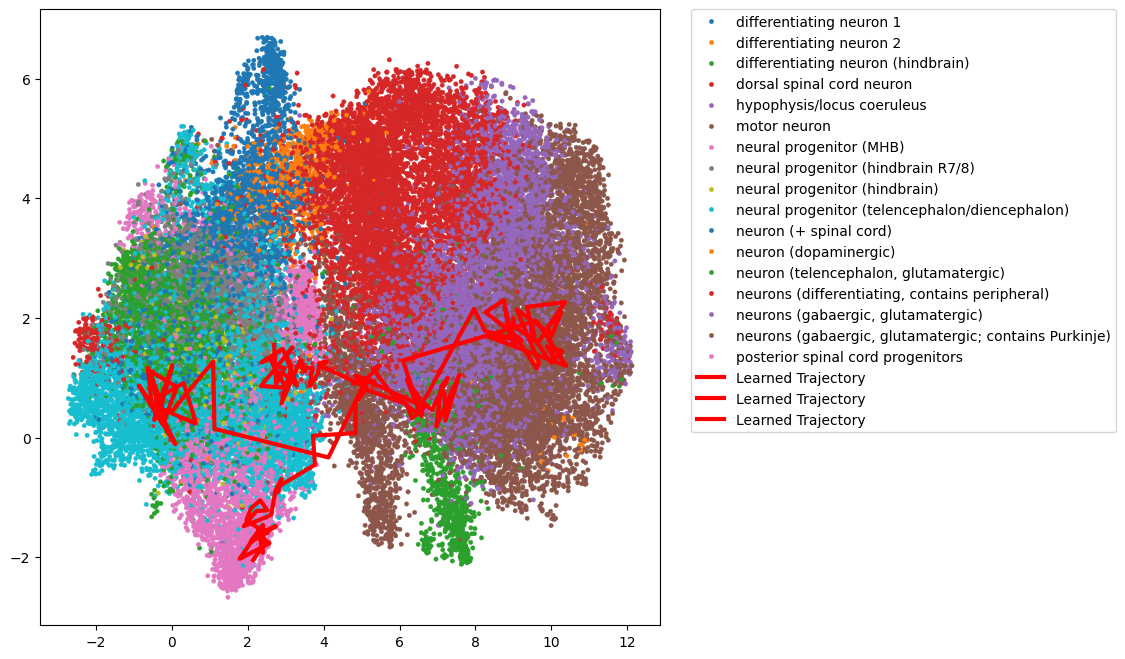

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [28]:

import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=adata.obs['cell_type'], # Directly pass the categorical column
    s=10,
    ax=ax,
    palette='tab10', # Or use a specific palette
    edgecolor=None   # Removes outlines for a cleaner look
)
for i in range(3):
    plt.plot(traj_umap[:, i, 0], traj_umap[:,i, 1], c='red', linewidth=3, label='Learned Trajectory')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

plt.figure(figsize=(8,8))

